# 📊 Sales Prediction Using Machine Learning

**Submitted By:** Tarannum Mohammad Nadaf  
**Organization:** Oasis Infobyte  
**Track:** Data Science  
**Project:** Sales Prediction Using Python

## Import Libraries

Import all the required Python libraries.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Load Dataset

Load the Advertising dataset.

In [2]:
df = pd.read_csv(r"Advertising.csv", index_col=0)

df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Exploratory Data Analysis (EDA)

Check the dataset information and statistics.

In [3]:
print("Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
print(df.describe())

Shape
(200, 4)

Columns
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Data Types
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistics
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


## Pair Plot

Visualize the relationship between all features.

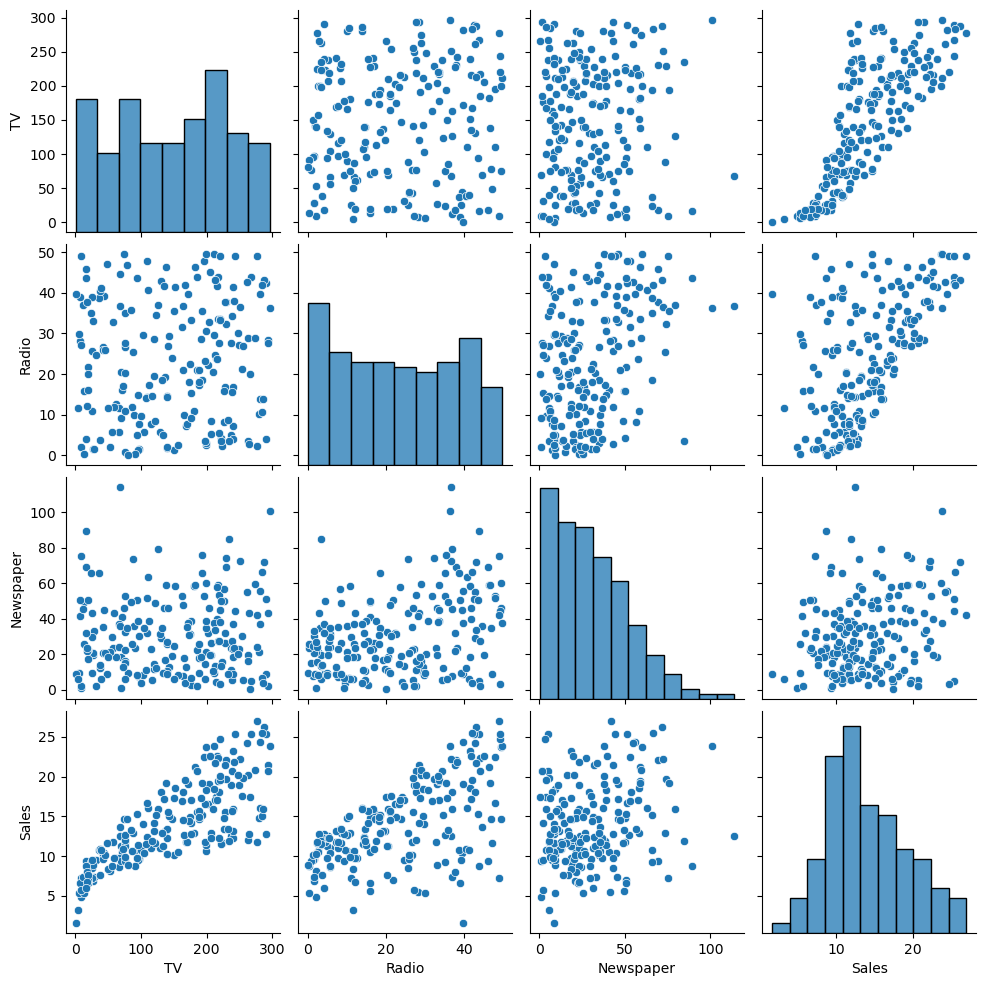

In [4]:
sns.pairplot(df)
plt.show()

## Scatter Plots

Visualize the relationship between advertising channels and sales.

## Scatter Plot

Visualize the relationship between TV advertising and Sales.

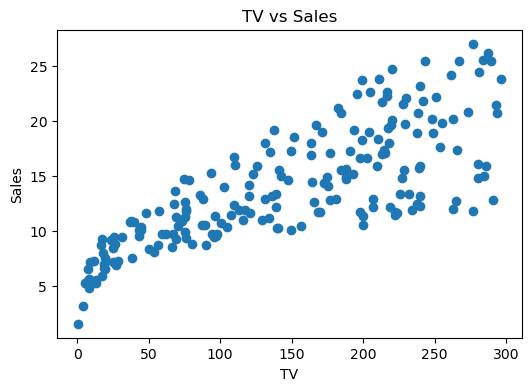

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(df["TV"], df["Sales"])
plt.title("TV vs Sales")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

## Scatter Plot

Visualize the relationship between Radio advertising and Sales.

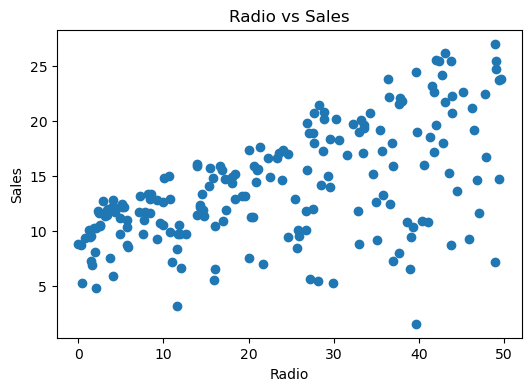

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(df["Radio"], df["Sales"])
plt.title("Radio vs Sales")
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.show()

## Scatter Plot

Visualize the relationship between Newspaper advertising and Sales.

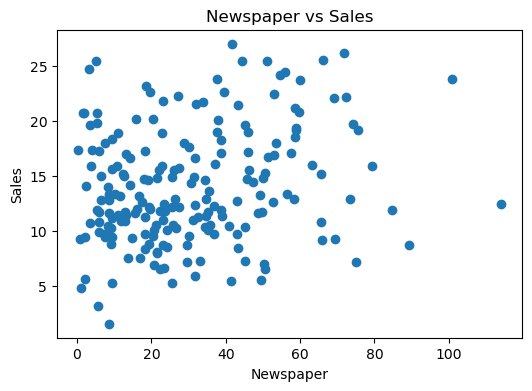

In [7]:
plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"], df["Sales"])
plt.title("Newspaper vs Sales")
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.show()

## Correlation Heatmap

Display the correlation between all features.

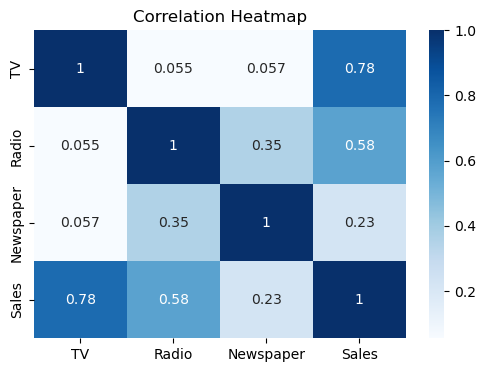

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## Feature Selection

Select input features (X) and target variable (y).

In [9]:
X = df.iloc[:, 0:3]
y = df.iloc[:, 3]

## Train-Test Split

Split the dataset into training and testing data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Verify Data

Check the shape of training and testing data.

In [11]:
print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (160, 3)
X_test Shape : (40, 3)
y_train Shape : (160,)
y_test Shape : (40,)


## Linear Regression

Train the Linear Regression model.

In [12]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

## Linear Regression Evaluation

Evaluate the Linear Regression model.

In [13]:
mae_lr = mean_absolute_error(y_test, pred_lr)
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

Linear Regression Results
-------------------------
MAE : 1.4607567168117606
RMSE: 1.7815996615334506
R² Score: 0.899438024100912


## Random Forest Regressor

Train the Random Forest Regression model.

In [14]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

## Random Forest Evaluation

Evaluate the Random Forest model.

In [15]:
mae_rf = mean_absolute_error(y_test, pred_rf)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R² Score: 0.9812843792541843


## Model Comparison

Compare the performance of both models.

In [16]:
print("Linear Regression R² Score :", r2_lr)
print("Random Forest R² Score :", r2_rf)

if r2_lr > r2_rf:
    print("\nBest Model : Linear Regression")
elif r2_rf > r2_lr:
    print("\nBest Model : Random Forest Regressor")
else:
    print("\nBoth Models Perform Equally Well")

Linear Regression R² Score : 0.899438024100912
Random Forest R² Score : 0.9812843792541843

Best Model : Random Forest Regressor


## Predict Sales

Predict sales using new advertising values.

In [17]:
sample = pd.DataFrame(
    [[150, 25, 30]],
    columns=X.columns
)

prediction = rf.predict(sample)

print("Predicted Sales :", round(prediction[0], 2))

Predicted Sales : 15.16


## Results

- Linear Regression R² Score: **0.8994**
- Random Forest R² Score: **0.9812**
- Predicted Sales : **15.16**
- Best Model: **Random Forest Regressor**

## Conclusion

The Sales Prediction project was completed using Linear Regression and Random Forest Regressor.

Both models were evaluated using MAE, RMSE, and R² Score.

The Random Forest Regressor achieved the highest R² Score (**0.9812**) and was selected as the best-performing model.

The trained model successfully predicted sales for new advertising values.